# 17.7 Sparse Autoencoder

#### Without L1 Regularization

##### Data

2023-07-31 05:26:25.786315: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


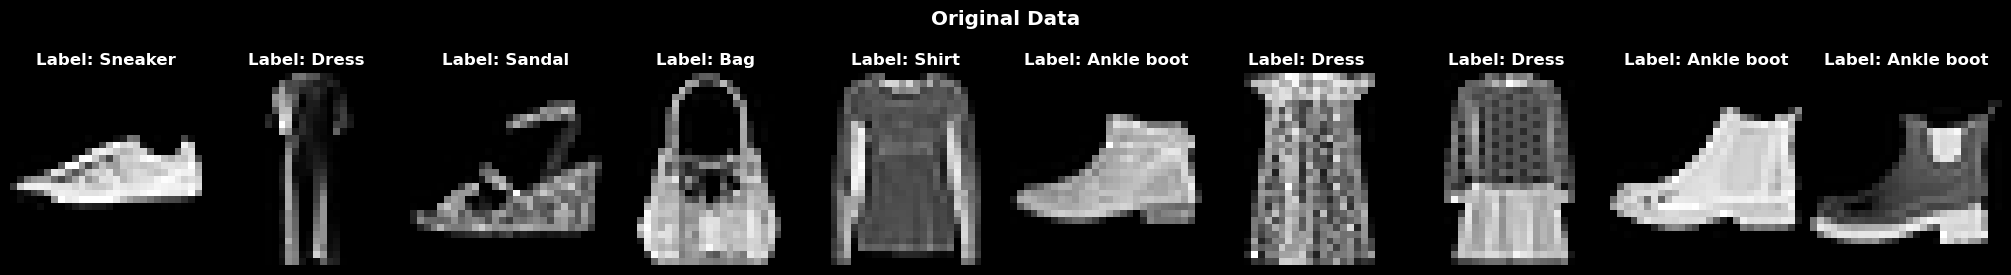

In [1]:
import load_fashion_mnist

(
    (x_train_norm, y_train),
    (x_valid_norm, y_valid),
    (x_test_norm, y_test),
) = load_fashion_mnist.load_data()

##### Model

In [2]:
import tensorflow as tf

encoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(
            100, activation="selu", kernel_initializer="lecun_normal"
        ),
        tf.keras.layers.Dense(
            300,
            activation="sigmoid",
            activity_regularizer=tf.keras.regularizers.l1(1e-3),
        ),
    ]
)
decoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(
            100,
            activation="selu",
            kernel_initializer="lecun_normal",
            input_shape=(300,),
        ),
        tf.keras.layers.Dense(28 * 28, activation="sigmoid"),
        tf.keras.layers.Reshape((28, 28)),
    ]
)
sparse_l1_ae = tf.keras.models.Sequential([encoder, decoder])

sparse_l1_ae.compile(optimizer="adam", loss="binary_crossentropy")
sparse_l1_ae.summary()

cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = sparse_l1_ae.fit(
    x_train_norm,
    x_train_norm,
    epochs=20,
    validation_data=[x_valid_norm, x_valid_norm],
    callbacks=[cb_early_stopping],
)

2023-07-31 05:26:30.111668: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-31 05:26:30.212536: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-31 05:26:30.212765: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-31 05:26:30.213458: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 300)               108800    
                                                                 
 sequential_1 (Sequential)   (None, 28, 28)            109284    
                                                                 
Total params: 218,084
Trainable params: 218,084
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
1500/1500 [==============================] - 5s 2ms/step - loss: 0.3476 - val_loss: 0.3148
Epoch 2/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.3081 - val_loss: 0.3028
Epoch 3/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2992 - val_loss: 0.2962
Epoch 4/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2940 - val_loss: 0.2923
Epoch 5/20
1500/1500 [==============

##### Evaluation

313/313 [==============================] - 0s 1ms/step


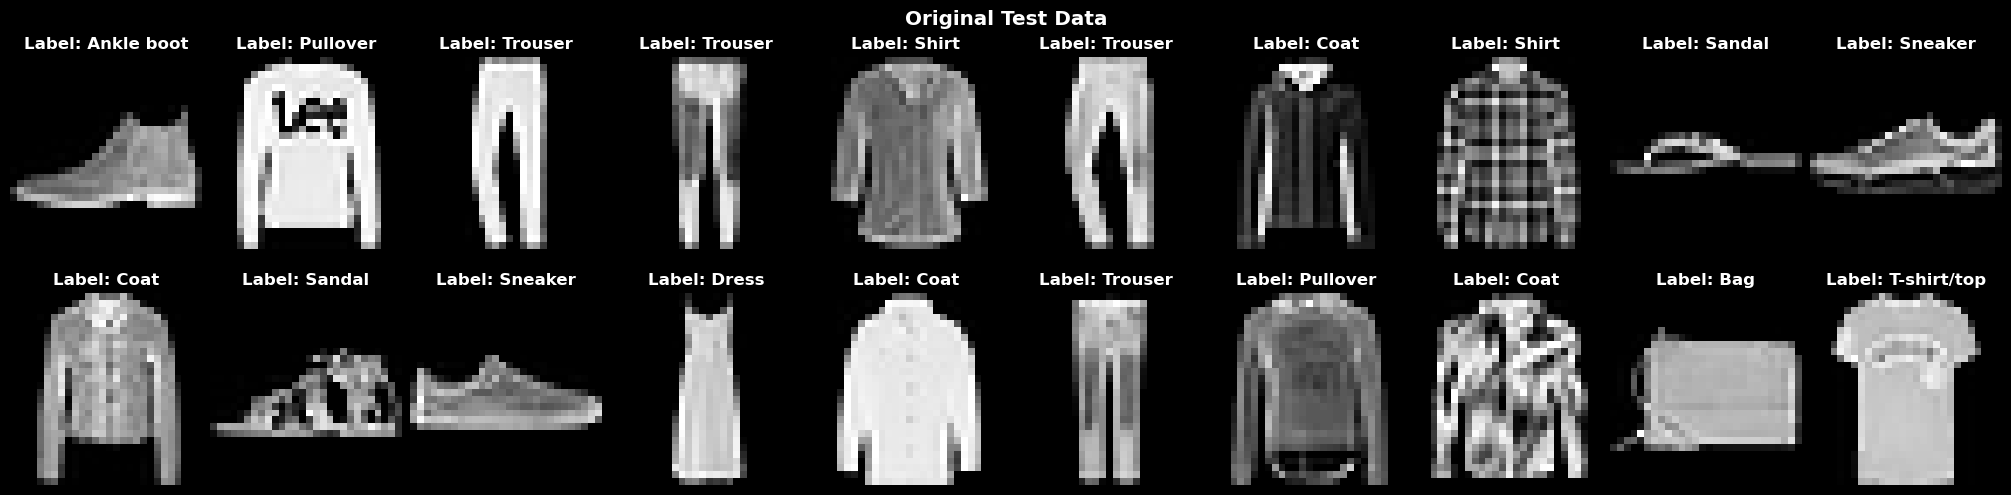

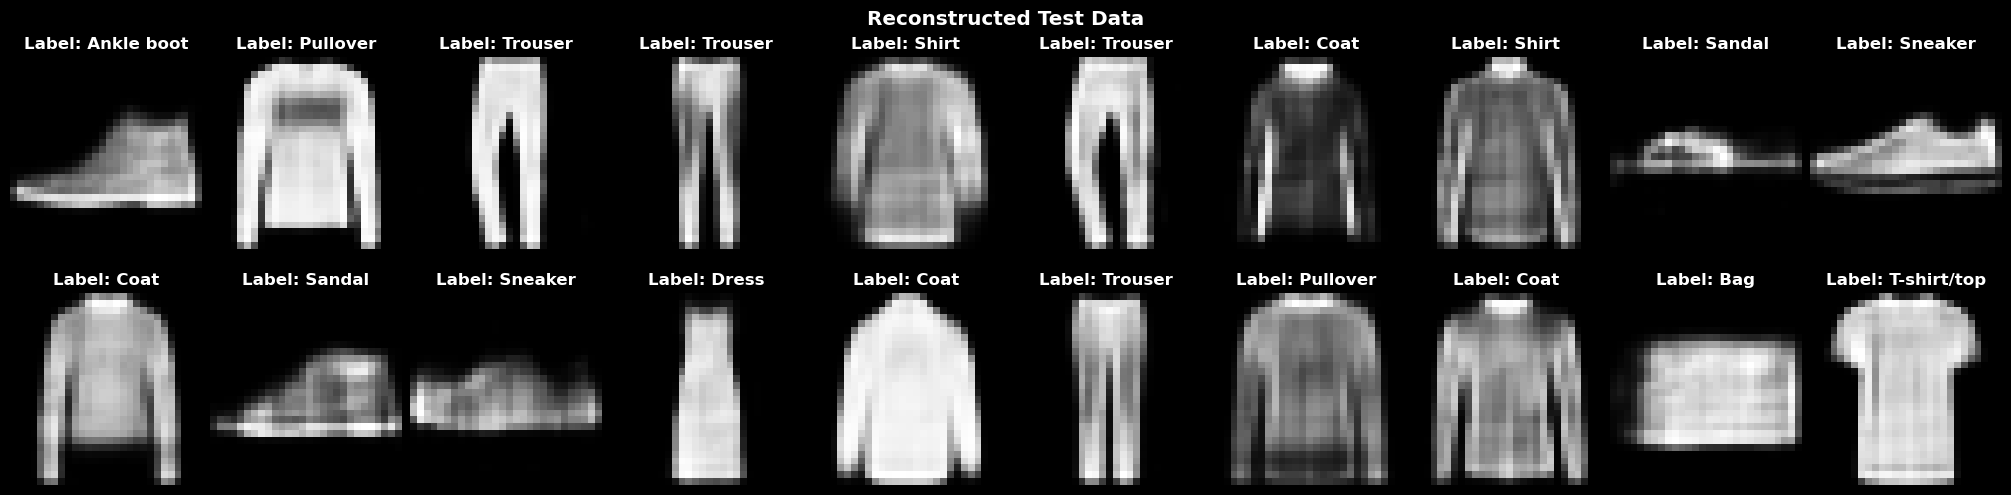

In [3]:
import evaluation

ev = evaluation.Evaluation(
    model=sparse_l1_ae,
    x_test=x_test_norm,
    y_test=y_test,
)
ev.reconstruction_test()

313/313 [==============================] - 0s 895us/step


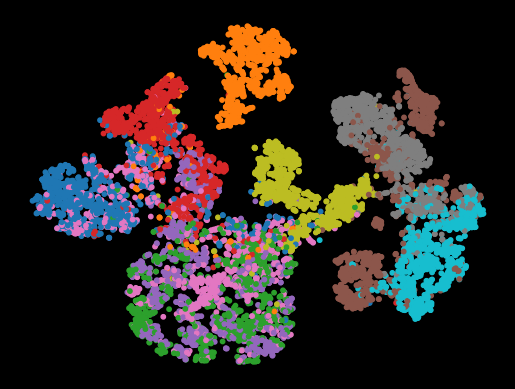

In [4]:
ev.dl_plot()

#### With KL Divergence Regularization

##### Model

In [13]:
class KLDivergenceRegularizer(tf.keras.regularizers.Regularizer):
    def __init__(self, weight: float, target: float = 0.1):
        self.weight = weight
        self.target = target

    def __call__(self, inputs: tf.Tensor) -> tf.Tensor:
        mean_activities = tf.keras.backend.mean(inputs, axis=0)
        return self.weight * (
            tf.keras.losses.kullback_leibler_divergence(self.target, mean_activities)
            + tf.keras.losses.kullback_leibler_divergence(
                1.0 - self.target, 1.0 - mean_activities
            )
        )

In [14]:
sparse_kl_encoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(
            100, activation="selu", kernel_initializer="lecun_normal"
        ),
        tf.keras.layers.Dense(
            300,
            activation="sigmoid",
            activity_regularizer=KLDivergenceRegularizer(0.05, 0.1),
        ),
    ]
)
sparse_kl_decoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(
            100,
            activation="selu",
            kernel_initializer="lecun_normal",
            input_shape=(300,),
        ),
        tf.keras.layers.Dense(28 * 28, activation="sigmoid"),
        tf.keras.layers.Reshape((28, 28)),
    ]
)
sparse_kl_ae = tf.keras.models.Sequential([sparse_kl_encoder, sparse_kl_decoder])

sparse_kl_ae.compile(optimizer="adam", loss="binary_crossentropy")
sparse_kl_ae.summary()

cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = sparse_kl_ae.fit(
    x_train_norm,
    x_train_norm,
    epochs=20,
    validation_data=[x_valid_norm, x_valid_norm],
    callbacks=[cb_early_stopping],
)

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (None, 300)               108800    
                                                                 
 sequential_7 (Sequential)   (None, 28, 28)            109284    
                                                                 
Total params: 218,084
Trainable params: 218,084
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.3321 - val_loss: 0.3012
Epoch 2/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2940 - val_loss: 0.2880
Epoch 3/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2844 - val_loss: 0.2814
Epoch 4/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2793 - val_loss: 0.2774
Epoch 5/20
1500/1500 [==============

##### Evaluation

313/313 [==============================] - 1s 1ms/step


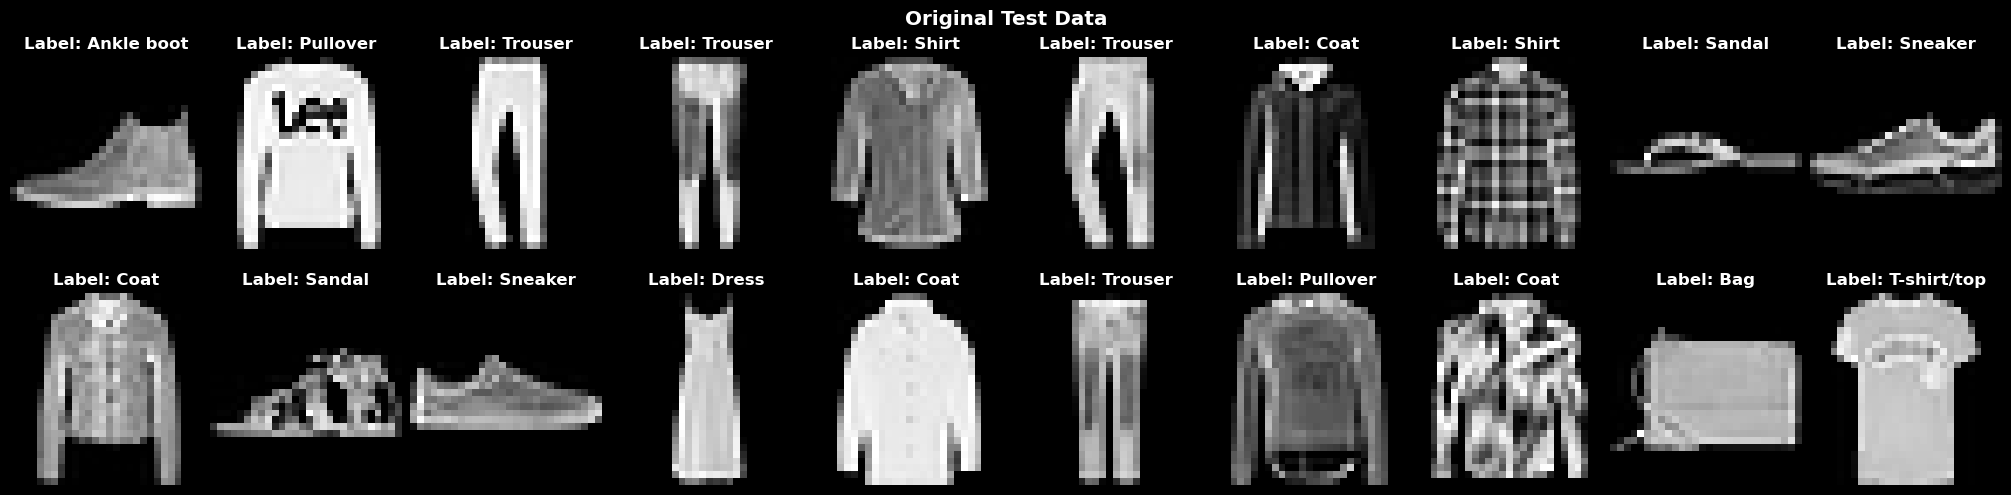

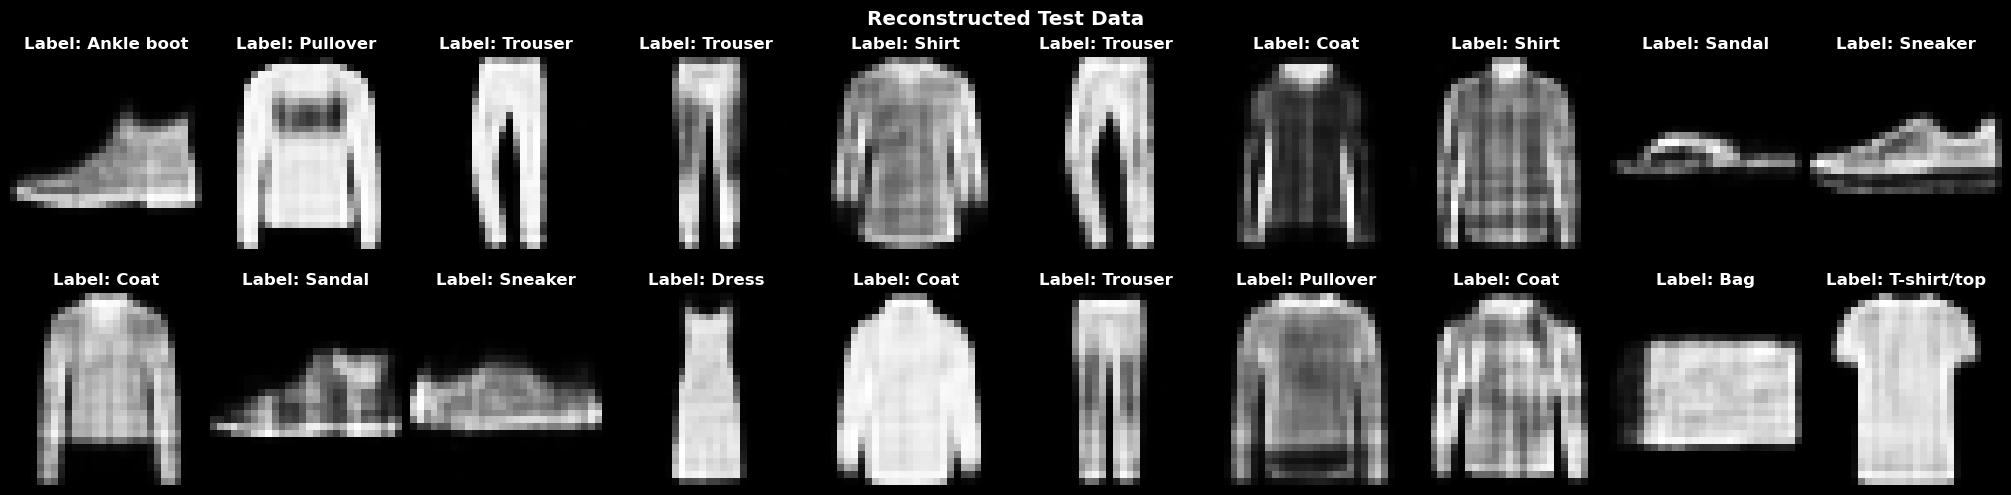

In [15]:
import evaluation

ev_kl = evaluation.Evaluation(
    model=sparse_kl_ae,
    x_test=x_test_norm,
    y_test=y_test,
)
ev_kl.reconstruction_test()

313/313 [==============================] - 1s 1ms/step


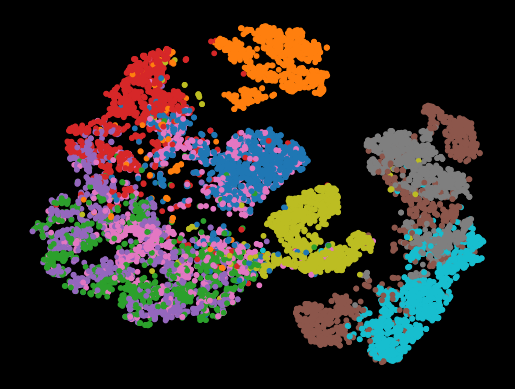

In [16]:
ev_kl.dl_plot()

313/313 [==============================] - 0s 899us/step


Text(0, 0.5, '% Neurons')

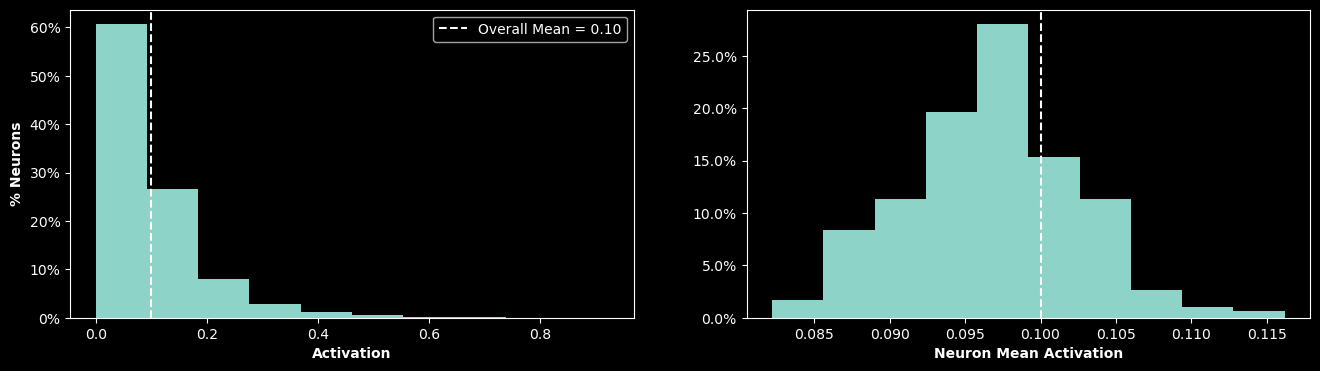

In [30]:
from typing import Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker


embeddings = sparse_kl_encoder.predict(x_test_norm)
data_hist_act = embeddings.flatten()
data_hist_neo = np.mean(embeddings, axis=0)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

for ax in axs:
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))

axs[0].hist(data_hist_act, weights=np.ones_like(data_hist_act) / len(data_hist_act))
axs[0].axvline(x=0.1, ls="dashed", label=f"Overall Mean = {np.mean(data_hist_act):.2f}")
axs[0].set_xlabel("Activation", fontweight="bold")
axs[0].set_ylabel("% Activations", fontweight="bold")
axs[0].legend()

axs[1].hist(data_hist_neo, weights=np.ones_like(data_hist_neo) / len(data_hist_neo))
axs[1].axvline(x=0.1, ls="--")
axs[1].set_xlabel("Neuron Mean Activation", fontweight="bold")
axs[0].set_ylabel("% Neurons", fontweight="bold")